# Demo 1 — Customer complaint classification
## From raw complaint data to a triage model

*AI Architecture — Day 1, live demo 1*

---

**Standard icon legend used in the notebook**

👉 key point / key takeaway  
📌 note / start of a note  
📦 important bullet point  
📊 data / figures  
🔹 regular bullet point  
⭐ important point  
✅ resolved / positive point  
❌ negative point / something to avoid  
⚠️ warning / attention required  
💡 key idea  
🧠 intuitive insight  
📝 summary / bottom line  
⟶ consequence / effect / next step  
🔧 notebook customization required here

---

### What we mean by "customer complaint"

A **customer complaint** is:
> a <u>formal statement of dissatisfaction</u> that a customer — a natural person or a
business — addresses to the bank <u>about a product, a service or the bank's conduct</u>, and to which the bank is
required to give <u>a written answer within a regulatory deadline</u>. 

👉 *The wording follows the definition adopted by the joint guidelines of the European supervisory authorities (EBA, ESMA and EIOPA) on complaints handling for
banking, securities and insurance; it is a paraphrase, not a quotation, and the bank's own complaints policy
remains the reference document*.

![](customer_complaint.png)

Three consequences for this notebook:

- **A complaint is a registered record.** It exists from the moment it is entered in the complaint-management
  system with an identifier (`complaint_id`), a date and the intake fields. Informal contacts that precede it
  — a call to the branch, a chat in the app, an e-mail asking for an explanation — are not complaints; they are
  counted in `contacts_before_complaint`.
- **A complaint has one outcome.** It is closed when the bank has answered and the case is settled: resolved
  at first contact, resolved after an investigation, or escalated by the customer to the **ombudsman** , the
  external alternative dispute resolution body for financial services <sup>1</sup>. In Italy this is the Arbitro Bancario
  Finanziario (ABF); for a bank operating in several countries the equivalent national body applies, and the
  label "Escalated to ombudsman" should be read in that generic sense. The outcome is the target of our model.
- **One complaint, one row.** A customer with several complaints appears several times; the same complaint
  never appears twice, which is why duplicated rows are a data-quality error and not a feature of the data.

Enquiries, service requests and feedback (i.e., messages without an expectation of redress <sup>2</sup>, which do not ask the
bank to put something right) are out of scope; so are complaints handled outside the bank's own process, for
example those received directly by the regulator.

<small>

<sup>1</sup>
*ombudsman*: an independent body that settles disputes between customers and firms out of court. In Italy: Arbitro Bancario Finanziario (ABF) for banking products, Arbitro per le Controversie Finanziarie (ACF) for investments. 

<sup>2</sup>
*redress*: in Italian, "ristoro", "risarcimento", the technical term used by Banca d'Italia e ABF. The expression "to redress a wrong" means "porre rimedio a / riparare un torto".
</small>

---

### The business situation

A bank receives **thousands of customer complaints** every year. Each complaint is logged in the
complaint-management system with structured attributes (product, channel, customer segment, disputed
amount, previous contacts, ...) and, when the complaint arrives in writing, with the text itself. 

### The life cycle of a complaint

A customer complaint goes through **four stages**. Each stage adds information to the record; a model can only use what
exists at the stage where it runs.

| Stage | What happens | What is recorded at this stage |
|---|---|---|
| **1. Intake** | The complaint is received (app, e-mail, web form, phone, branch, social media) and registered in the complaint-management system | product, channel, customer segment, customer age and tenure, disputed amount, previous contacts and complaints, days since the event, the text if written |
| **2. Triage** | Priority and handler are assigned; the fast lane or the specialist team | priority, assigned team |
| **3. Handling** | Investigation, contacts with the customer, reply | investigation notes, reply date, first-response time |
| **4. Closure** | The case is closed with an outcome; compensation paid if due; root cause classified | outcome (our target), compensation paid, root cause |

The same with a picture:<br>

![](complaint_lifecycle.png)

---
### The business question

*Can we predict, the moment a complaint is filed (ie, at the the intake step), how it will end? Compensation will be due or not? Escalation (to a grand jury) will be required?*

If we can, we can **triage**: route likely escalations to senior handlers immediately, offer a goodwill
gesture early, and keep the simple cases in the fast lane.

**Opportunities**

- **Cost.** Escalations are the expensive tail: handling time, ombudsman fees, compensation.
- **Deadlines.** Regulators impose reply deadlines (for example 15 business days for payment-service
  complaints under PSD2). A late answer is itself a reason to escalate.
- **Retention.** A complaint handled well is a loyalty moment; handled badly, it often precedes churn.
- **Early warning.** Complaint volumes are a sensor for operational incidents and product problems.

**Risks**

- **Data quality.** The model learns from what was logged, errors included. This is why most of the demo is
  about looking at the data before modelling it.
- **Leakage.** Using information that is not available at intake makes a model look brilliant in the lab and
  useless in production.
- **Fairness and compliance.** Triage must not systematically de-prioritise a group of customers
  (GDPR rules on profiling; EU AI Act principles of oversight and transparency).
- **Automation bias.** A prediction is a suggestion for the handler, not a decision.

---
### Three classifiers, three different questions

In a bank, three kinds of complaint classifier can be used:

- a **text classifier**
- a **triage classifier**
- an **outcome classifier**

All three are classifiers in the machine-learning sense: each assigns one label from a fixed set to an input.
What changes is *what* is classified, *where the labels come from* and *what the output is used for*. Keeping
them apart avoids most of the confusion around "complaint classification".

| | 1. Text classifier | 2. Triage classifier | 3. Outcome classifier (this notebook) |
|---|---|---|---|
| **Question answered** | What does this text say, and in what tone? | What should we do with this complaint? | How will this complaint end? |
| **Input** | The text of the complaint | The intake record (structured fields, plus the outputs of the text classifier) | The intake record (structured fields, plus the outputs of the text classifier) |
| **Output (label)** | Two labels, asked for in the same call: a **topic** (Fees, Fraud, Mortgage…) and a **tone**. The tone can be expressed as a sentiment score from −1 to +1 (as in this demo) or as an ordinal tone level (calm / annoyed / angry / threatening escalation). Only the tone is used downstream here; the topic is a bonus of the same call. | A priority or a route: fast lane, standard, senior handler | One of the three outcomes: resolved at first contact, resolved after investigation, escalated to the ombudsman |
| **Where the labels come from** | People reading and tagging texts — or, in the LLM version, no labels at all: the model is instructed by a prompt | Past decisions of handlers: what they assigned | Facts recorded at closure: what actually happened |
| **What it learns** | The language of complaints | The **behaviour of the handlers**, including their inconsistency and their bias | The **relationship between the case and its outcome** |
| **Typical technique** | LLM with a prompt (next demo); or a small text model trained on labelled texts | Supervised classifier on historical priorities, or a rule applied to the outcome model | Classical supervised model on structured data (logistic regression, trees, random forest) |
| **Role in the flow** | Produces features (`sentiment_score`, topic) for the models downstream | Turns a prediction into an action | Produces the probability that the triage rule uses |

How the three fit together in this demo:

- **First, the text classifier** runs on the written complaints: an LLM reads the excerpt and returns a tone
  score and a topic. Its output becomes a column of the complaint table. Designing, testing and costing that
  step is the subject of the next demo, on prompt engineering.
- **Then the outcome classifier** — the model built here — takes the intake record, including that column,
  and returns the probability of each outcome. Its labels are facts, not opinions, which is what makes it
  trainable and auditable: we can measure accuracy against what really happened.
- **Finally, the triage decision** is not a trained classifier but a **rule** on top of the outcome
  probabilities — for example, "route to a senior handler when P(escalated) ≥ 0.30" — whose threshold the
  business sets by weighing the cost of a missed escalation against the cost of a false alarm. A bank that
  holds a history of priorities assigned by experienced handlers could train a triage classifier instead; it
  would replicate their judgement, good and bad, and it would be harder to evaluate, because "the right
  priority" is an opinion while "the outcome" is a fact.

👉 One consequence for the vocabulary of the course: when we say that the model "classifies complaints", we
mean the **outcome classifier** (column 3 of the table above). The **text classifier** (column 1) is the one
people usually have in mind when they hear "complaint classification"; in this notebook it is a supplier of
features, not the model under study.


---
### Role of the outcome classifier

This notebook builds a **predictive model** that runs at **intake** and supports **triage**: it predicts the outcome of
stage 4 using only the information of stage 1. Everything recorded in stages 2–4 is a consequence of the
handling, not an input to it.
The handling of a complaint by the classifier will end in one of three ways:

| Outcome | What it means for the bank |
|---|---|
| **Resolved at first contact** | closed by the front line, low cost |
| **Resolved after investigation** | back-office work, days or weeks of handling |
| **Escalated to ombudsman** | the customer goes to the external dispute body: fees, compensation, reputational damage, regulatory attention |

A classical ML model cannot read text: before the data reach the model, an **LLM reads each complaint and returns a "sentiment
score"** from −1 (very negative) to +1 (positive), which becomes a numeric column like any other. Section 3
runs that step **live on a few complaints** to show the mechanism; the input file <u>already contains the resulting column (ie, the sentiment score)
for all written complaints</u>, so the rest of the notebook does not depend on the model API. How to design, test and
cost such a prompt is the subject of the prompt-engineering demo (later).

The above summarized in a picture:<br>
![](role_classifier.png)

---
### Read this first: assumptions and simplifications

This demo is built on a **synthetic dataset** and on a number of **deliberate choices**. They are listed here so that
nobody has to guess them while reading the notebook.

| Topic | What we assume in this demo | Why it matters |
|---|---|---|
| **What is classified** | The **outcome** of a complaint (*resolved at first contact* / *resolved after investigation* / *escalated to the ombudsman*), not its topic. It is the same kind of model as a default or fraud classifier: a probability, then a **decision rule** (e.g., the priority assigned at triage). | "Complaint classification" often means triage, or the classification of the text by topic; here the topic appears only in the LLM step. See "Three classifiers, three different questions" below. |
| **Moment of use** | The model runs at **intake** — the moment a complaint is received and registered — with the fields known at that point: product, channel, customer segment, disputed amount, previous contacts, and the text if the complaint is written. Anything recorded <u>later</u> in the life cycle is not a legitimate feature: `compensation_eur` is known only at closure and is used in the notebook only to show *data leakage*. | The moment of use fixes the perimeter of the data a model may learn from. |
| **The data** | 3,000 **synthetic** complaints (3,006 rows in the file, six of them duplicates), January 2025 – June 2026, generated by the companion notebook `01_generate_complaints_dataset.ipynb` with a fixed seed. Every pattern (severity cluster, channel effects, February 2026 incident, missing values, outliers, duplicates) is injected on purpose; none is observed in a real bank. | Insights are teaching material, not findings about complaints in general. |
| **The text and the LLM** | `complaint_excerpt` holds the opening lines of a written complaint (20–75 words, 35 on average); `text_length_words` refers to the full complaint. An LLM (OpenAI API, model `gpt-4o-mini`, key in the environment variable `OPENAI_API_KEY`) is called **live on a few complaints** in sections 3 and 9. The `sentiment_score` column in the input file was **generated with the synthetic data**, not by the LLM, to keep the demo simple. The score already in the file (`stored sentiment`) and the score the LLM returns now (`LLM sentiment`) should have the same sign and a similar magnitude — a furious complaint scores strongly negative in both, a polite one close to zero or positive — but do not expect them to match to the decimal: an LLM's ratings are themselves not perfectly repeatable. | Without the `openai` package or the key, the LLM cells are skipped and the notebook still runs end to end. |
| **The excerpt is not a feature** | The text enters the model only through `sentiment_score` (and `text_length_words`); the excerpt itself is never encoded. | Keeps the model classical and explainable. |
| **Missing values** | Mechanisms are by construction: `customer_age` MCAR, text-derived columns MAR (no written text for most branch and phone complaints), `disputed_amount` MNAR (large claims left blank), `customer_segment = "unknown"` as a missing value written as text. | Section 5 shows the evidence one would look for in real data. |
| **Outliers** | Injected in three families: univariate (impossible ages, cents keyed as euros, pasted documents), bivariate (tenure longer than adult life, new customers with 7–8 products), multivariate (visible only with the Mahalanobis distance). The trainer holds the list in `bank_complaints_answer_key.csv`. | The exercise is to find them with the tools, not to know them. |
| **Metrics** | Accuracy and the confusion matrix only, by course design; the baseline is the majority class (about 48%). | Enough for the demo; a project would add recall on the escalations and cost-weighted measures. |
| **Preparation** | Imputation values (medians) are computed on the whole dataset before the train/test split, and encoding is done once with `get_dummies`. | A simplification for readability; a production pipeline fits these on the training set only. |
| **Decision rule and business numbers** | The routing threshold (P(escalated) ≥ 0.30) and the business targets quoted (accuracy above 70%, escalations −20%) are illustrative choices for the story, not recommendations. | The threshold is a business decision on the cost of a miss versus a false alarm. |
| **Regulatory references** | Mentions of PSD2, GDPR and the EU AI Act are simplified and used as context only. | Verify against the bank's own compliance guidance. |
| **Environment** | Python 3.10+, `pandas` 2.x or 3.x, `scikit-learn` ≥ 1.3, `matplotlib`, `plotly` + `nbformat`, `openai` (optional); VS Code with the Jupyter extension; the CSV in the same folder as the notebook. | Cross-validation and grid search run in well under a minute on a laptop. |

![](demo_workflow.png)


---
### How the demo unfolds

1. Load the data and take a first look
2. Data-quality checks (duplicates, inconsistent labels)
3. From text to numbers: the LLM step, live on a few complaints
4. Exploratory data analysis (EDA)
5. Missing values: mechanisms and strategies
6. Outliers: from the box plot to the Mahalanobis distance
7. Cleaning decisions and feature preparation (including the leakage trap)
8. Three classification models: train/test split, cross-validation, hyper-parameter tuning
9. Predictions on new complaints
10. Business wrap-up

The above in a picture:

![](demo_unfolding.png)

📌 **A note for the technical audience.** 
>
> The code is deliberately plain: `pandas`, `matplotlib`, `plotly`
and `scikit-learn`, no custom functions or pipelines beyond the strict minimum. In a production project
much of this would be packaged and automated; here readability wins. The LLM cells need the `openai`
package and an API key; without them they are skipped automatically and the notebook still runs end to end.


---
### Data dictionary

| Column | Meaning | Known at intake? |
|---|---|---|
| `complaint_id` | unique identifier assigned by the complaint-management system (e.g., `CMP-000123`) | yes |
| `complaint_date` | date the complaint was registered (e.g., `2026-02-05`) | yes |
| `product` | product the complaint refers to (e.g., Current account, Credit card, Mortgage, Investments, Personal loan, Insurance) | yes |
| `channel` | channel used to complain (e.g., Phone, Email, Mobile app, Web form, Branch, Social media) | yes |
| `customer_segment` | commercial segment of the customer: Retail, Affluent, SME (small and medium enterprises), Private (private banking) | yes |
| `customer_age` | age in years at the date of the complaint (e.g., 46) | yes |
| `tenure_years` | years as a customer of the bank (e.g., 9.5); cannot exceed `customer_age − 18` | yes |
| `products_held` | number of products held with the bank, from 1 to 8 (e.g., current account + card + mortgage = 3) | yes |
| `disputed_amount` | amount claimed by the customer, in EUR, as keyed by the operator (e.g., 245.60 for a duplicated card payment) | yes |
| `prior_complaints_12m` | complaints filed by the same customer in the previous 12 months (0 for most customers) | yes |
| `contacts_before_complaint` | informal contacts about the same issue before the formal complaint (e.g., 3 calls to the branch and one chat in the app = 4) | yes |
| `days_since_event` | days between the disputed event and the registration of the complaint (e.g., a charge on 12 May, complaint on 30 May = 18) | yes |
| `text_length_words` | length of the full written complaint, in words (e.g., 180) | yes (if written) |
| `sentiment_score` | tone of the text, from −1 (very negative, e.g., "I am furious, I will go to the ombudsman") to +1 (positive, e.g., "thank you in advance for looking into it"), 0 neutral; produced by the LLM step | yes (if written) |
| `complaint_excerpt` | opening lines of the written complaint, the input of the LLM step (e.g., "My card was charged twice for the same purchase of 245 euros…") | yes (if written) |
| `compensation_eur` | compensation paid to the customer at closure, EUR (e.g., 0 for most first-contact resolutions; the refund plus the ombudsman fee for an escalation) | **no — post-closure** |
| `outcome` | **target**: how the complaint ended (Resolved at first contact / Resolved after investigation / Escalated to ombudsman) | **no — this is what we predict** |

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px                  # if missing: pip install plotly nbformat
from scipy.stats import chi2

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4)

# a small palette reused in the plots: teal, purple, coral, grey
TEAL, PURPLE, CORAL, GREY = "#0F766E", "#6D28D9", "#E8674A", "#4B5563"
OUTCOME_ORDER = ["Resolved at first contact", "Resolved after investigation", "Escalated to ombudsman"]
OUTCOME_COLORS = {"Resolved at first contact": TEAL, "Resolved after investigation": PURPLE, "Escalated to ombudsman": CORAL}

## 1. Load the data and take a first look

The file is a plain CSV export of the complaint-management system. We ask `pandas` to parse the date column
while reading, so that it becomes a real date and not a string.

In [22]:
df = pd.read_csv("bank_complaints.csv", parse_dates=["complaint_date"])
print("Rows:", df.shape[0], "  Columns:", df.shape[1])
df.head()

Rows: 3006   Columns: 17


,complaint_id,complaint_date,product,channel,customer_segment,customer_age,tenure_years,products_held,disputed_amount,prior_complaints_12m,contacts_before_complaint,days_since_event,text_length_words,sentiment_score,complaint_excerpt,outcome,compensation_eur
0,CMP-000001,2025-01-01,Credit card,Phone,Retail,57.0,10.2,4.0,93.51,0.0,1.0,18.0,NaN,NaN,NaN,Resolved at first contact,0.00
1,CMP-000002,2025-01-01,Mortgage,Mobile app,SME,30.0,1.1,2.0,NaN,1.0,2.0,36.0,174.0,-0.52,"The interest rate applied to my mortgage does not match the offer I signed, and I have overpaid 3,574 euro...",Resolved after investigation,783.79
2,CMP-000003,2025-01-01,Investments,Email,Affluent,49.0,8.8,5.0,1421.76,1.0,4.0,26.0,176.0,-0.69,"I asked to sell my fund units on the 5th; the order was executed days later at a loss of 1,422 euros. I ha...",Resolved after investigation,406.57
3,CMP-000004,2025-01-01,Mortgage,Phone,unknown,37.0,1.3,1.0,733.81,2.0,2.0,38.0,NaN,NaN,NaN,Resolved after investigation,300.69
4,CMP-000005,2025-01-01,Mortgage,Web form,Retail,47.0,6.0,2.0,749.28,0.0,2.0,38.0,205.0,-0.35,An insurance premium of 749 euros was added to my mortgage instalment without my consent. I expect a refun...,Resolved after investigation,0.00


**Data types.** A quick check of `dtypes` already tells a story: `customer_age` is a float although ages are
whole numbers. `pandas` stores a column as float as soon as it contains a missing value (`NaN`), so a float
column of counts is often the first sign of missing data.

In [23]:
df.dtypes

complaint_id                            str
complaint_date               datetime64[us]
product                                 str
channel                                 str
customer_segment                        str
customer_age                        float64
tenure_years                        float64
products_held                       float64
disputed_amount                     float64
prior_complaints_12m                float64
contacts_before_complaint           float64
days_since_event                    float64
text_length_words                   float64
sentiment_score                     float64
complaint_excerpt                       str
outcome                                 str
compensation_eur                    float64
dtype: object

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3006 entries, 0 to 3005
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   complaint_id               3006 non-null   str           
 1   complaint_date             3006 non-null   datetime64[us]
 2   product                    3006 non-null   str           
 3   channel                    3006 non-null   str           
 4   customer_segment           3006 non-null   str           
 5   customer_age               2883 non-null   float64       
 6   tenure_years               3006 non-null   float64       
 7   products_held              3006 non-null   float64       
 8   disputed_amount            2755 non-null   float64       
 9   prior_complaints_12m       3006 non-null   float64       
 10  contacts_before_complaint  3006 non-null   float64       
 11  days_since_event           3006 non-null   float64       
 12  text_length_words

**Numeric summary.** `describe()` gives count, mean, standard deviation and quartiles. Three things to read here:

- the `count` differs across columns: some have missing values;
- the `mean` of `disputed_amount` is far above its median (`50%`): the distribution is skewed, with a long tail of
  large amounts;
- the `max` values of `customer_age`, `text_length_words` and `days_since_event` look suspicious.

In [25]:
df.describe().round(2).T

,count,mean,min,25%,50%,75%,max,std
complaint_date,3006,2025-10-12 05:33:53.532934,2025-01-01 00:00:00,2025-05-22 06:00:00,2025-11-03 00:00:00,2026-02-13 00:00:00,2026-06-30 00:00:00,NaN
customer_age,2883.0,46.93,18.0,38.0,46.0,56.0,134.0,13.61
tenure_years,3006.0,9.01,0.0,3.92,8.6,13.3,30.7,6.34
products_held,3006.0,4.0,1.0,2.0,4.0,5.0,8.0,1.95
disputed_amount,2755.0,1014.81,7.66,168.62,417.05,957.46,135908.0,3733.34
prior_complaints_12m,3006.0,0.93,0.0,0.0,1.0,1.0,4.0,0.83
contacts_before_complaint,3006.0,2.4,0.0,1.0,2.0,3.0,7.0,1.42
days_since_event,3006.0,26.15,0.0,16.0,26.0,35.0,1450.0,29.6
text_length_words,2247.0,172.48,20.0,123.0,163.0,201.5,12400.0,333.38
sentiment_score,2246.0,-0.3,-1.0,-0.52,-0.31,-0.11,0.65,0.3


**Non-numeric columns.** For text and date columns `describe()` reports the number of distinct values and
the most frequent one. Note the number of distinct values of `channel`: we expect 6 channels.

In [26]:
df.select_dtypes(exclude="number").describe().T

,count,mean,min,25%,50%,75%,max
complaint_date,3006,2025-10-12 05:33:53.532934,2025-01-01 00:00:00,2025-05-22 06:00:00,2025-11-03 00:00:00,2026-02-13 00:00:00,2026-06-30 00:00:00


## 2. Data-quality checks

Before any analysis we look for the two most common defects of a system export: duplicated rows and
inconsistent category labels.

> **Business insight.** A `value_counts()` on every categorical column is the cheapest data-quality check
> there is, and it catches problems that no model can fix afterwards.

In [27]:
print("Exact duplicate rows:", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values("complaint_id").head(6)

Exact duplicate rows: 6


,complaint_id,complaint_date,product,channel,customer_segment,customer_age,tenure_years,products_held,disputed_amount,prior_complaints_12m,contacts_before_complaint,days_since_event,text_length_words,sentiment_score,complaint_excerpt,outcome,compensation_eur
646,CMP-000647,2025-05-02,Credit card,Branch,SME,61.0,12.3,4.0,5772.19,2.0,6.0,59.0,264.0,-0.61,"There is a transaction of 5,772 euros on my card statement that I never made. I have already called 6 time...",Escalated to ombudsman,2948.66
647,CMP-000647,2025-05-02,Credit card,Branch,SME,61.0,12.3,4.0,5772.19,2.0,6.0,59.0,264.0,-0.61,"There is a transaction of 5,772 euros on my card statement that I never made. I have already called 6 time...",Escalated to ombudsman,2948.66
771,CMP-000771,2025-05-29,Insurance,Web form,Private,48.0,3.1,5.0,NaN,2.0,5.0,14.0,197.0,-0.55,The insurance policy was renewed and 821 euros charged although I had cancelled it in writing. I have alre...,Escalated to ombudsman,773.34
772,CMP-000771,2025-05-29,Insurance,Web form,Private,48.0,3.1,5.0,NaN,2.0,5.0,14.0,197.0,-0.55,The insurance policy was renewed and 821 euros charged although I had cancelled it in writing. I have alre...,Escalated to ombudsman,773.34
830,CMP-000829,2025-06-10,Current account,Phone,Affluent,NaN,11.3,5.0,750.44,1.0,3.0,30.0,208.0,-0.42,An unauthorised direct debit of 750 euros was taken from my current account on the 18th. This is my third ...,Resolved after investigation,282.81
831,CMP-000829,2025-06-10,Current account,Phone,Affluent,NaN,11.3,5.0,750.44,1.0,3.0,30.0,208.0,-0.42,An unauthorised direct debit of 750 euros was taken from my current account on the 18th. This is my third ...,Resolved after investigation,282.81


In [28]:
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 3000


In [29]:
for col in ["product", "channel", "customer_segment", "outcome"]:
    print(df[col].value_counts(dropna=False), "\n")

product
Current account    1048
Credit card         699
Mortgage            359
Investments         341
Personal loan       316
Insurance           237
Name: count, dtype: int64 

channel
Phone           901
Email           615
Mobile app      600
Web form        379
Branch          352
Social media    141
E-mail            5
email             4
Phone             3
Name: count, dtype: int64 

customer_segment
Retail      1952
Affluent     588
SME          264
Private      156
unknown       40
Name: count, dtype: int64 

outcome
Resolved at first contact       1430
Resolved after investigation    1146
Escalated to ombudsman           424
Name: count, dtype: int64 



⚠️ Two problems appear:

- `channel` has spelling variants (`E-mail`, `email`, `Phone ` with a trailing space) that a model would treat as
  different channels;
- `customer_segment` contains the word `unknown`, which is a missing value written as text. `pandas` recognises
  empty cells as missing, but not the word "unknown".

We normalise the labels and turn `unknown` into a proper missing value, so that it is handled together with
the other missing values in section 5.

In [31]:
df["channel"] = df["channel"].str.strip().replace({"E-mail": "Email", "email": "Email"})
df["customer_segment"] = df["customer_segment"].replace("unknown", np.nan)

print(df["channel"].value_counts(), "\n")
print(df["customer_segment"].value_counts(dropna=False))

channel
Phone           904
Email           624
Mobile app      600
Web form        379
Branch          352
Social media    141
Name: count, dtype: int64 

customer_segment
Retail      1952
Affluent     588
SME          264
Private      156
NaN           40
Name: count, dtype: int64


## 3. From text to numbers: the LLM step

![](llm_step.png)

The models of this notebook work on numbers and categories. The tone of a complaint is in its text, so a
step upstream turns the text into a number: an LLM receives the complaint with a short instruction and returns
a **structured answer** (a small JSON object) with the sentiment score and the topic. The score is then stored
in the complaint table as `sentiment_score`, next to the amount and the channel.

We run that step live on five written complaints, with the minimum needed to see the flow: a client for the
LLM API, a prompt, a loop over the complaints, a table with the answers. Everything that makes the step
good in production — the wording of the prompt, examples, testing against labelled data, model choice,
cost per thousand complaints — is left to the prompt-engineering demo.

The demo file already contains `sentiment_score` for all written complaints, so the rest of the notebook
runs without an API key: if the key or the `openai` package is missing, the two cells below simply report it
and are skipped.

In [11]:
import os
import json

LLM_MODEL = "gpt-4o-mini"        # a small, cheap model is enough for this task; any current small model works

try:
    from openai import OpenAI     # pip install openai
    RUN_LLM = os.environ.get("OPENAI_API_KEY") is not None
except ImportError:
    RUN_LLM = False

if RUN_LLM:
    client = OpenAI()             # reads the key from the OPENAI_API_KEY environment variable
    print("LLM client ready, model:", LLM_MODEL)
else:
    print("openai package or OPENAI_API_KEY not found: the live LLM cells are skipped, the stored sentiment_score is used.")

openai package or OPENAI_API_KEY not found: the live LLM cells are skipped, the stored sentiment_score is used.


In [12]:
SYSTEM_PROMPT = """You are a complaints analyst at a retail bank.
Read the customer complaint and return a JSON object with two fields:
- "sentiment": a number from -1 (very negative, angry) to 1 (positive); 0 is neutral
- "category": one of "Fees", "Fraud", "Service quality", "Mortgage", "Investments", "Other"
Answer with the JSON object only."""

# five written complaints spread over the whole range of tone: the most negative, three in between, the most positive
written = df[df["complaint_excerpt"].notna()].sort_values("sentiment_score")
sample = written.iloc[[0, len(written) // 4, len(written) // 2, 3 * len(written) // 4, len(written) - 1]]
comparison = sample[["complaint_id", "product", "complaint_excerpt", "sentiment_score"]].rename(columns={"sentiment_score": "stored sentiment"})

if RUN_LLM:
    llm_sentiment, llm_category = [], []
    for text in sample["complaint_excerpt"]:
        response = client.chat.completions.create(
            model=LLM_MODEL,
            temperature=0,                                   # as repeatable as possible (remove for models that do not accept it)
            response_format={"type": "json_object"},         # the answer must be valid JSON
            messages=[{"role": "system", "content": SYSTEM_PROMPT},
                      {"role": "user", "content": "Complaint:\n<<<\n" + text + "\n>>>"}])
        answer = json.loads(response.choices[0].message.content)
        llm_sentiment.append(answer["sentiment"])
        llm_category.append(answer["category"])
    comparison["LLM sentiment"] = llm_sentiment
    comparison["LLM category"] = llm_category

pd.set_option("display.max_colwidth", 110)
comparison

,complaint_id,product,complaint_excerpt,stored sentiment
2988,CMP-002989,Current account,A transfer of 489 euros I sent on the 6th never reached the beneficiary and nobody can tell me where it is...,-1.00
1,CMP-000002,Mortgage,"The interest rate applied to my mortgage does not match the offer I signed, and I have overpaid 3,574 euro...",-0.52
2054,CMP-002055,Current account,The mobile app has been down for two days and my payment of 68 euros bounced. I am very disappointed with ...,-0.30
2557,CMP-002558,Insurance,My claim of 443 euros on the policy linked to my account was rejected without any explanation. Please let ...,-0.10
1229,CMP-001230,Current account,I was charged 111 euros in fees that were never mentioned when I opened the account. I have always been ha...,0.65


**What to notice.** The LLM returns the same two fields for every complaint, on the scale we asked for: that
is what makes its answer usable as a column. The live score and the stored one should agree in sign and
roughly in size, not to the second decimal: the stored values were produced when the dataset was built, and an
LLM's ratings are not perfectly repeatable. The topic (`category`) is a bonus of the same call: in a real
system it would be a second feature, or the input of a routing rule of its own.

> **Business reading.** One prompt, one call per complaint, and a free-text field becomes a measurable
> signal for the whole complaints history. The cost is a few thousand tokens per hundred complaints; the risk is
> a score nobody has validated. Both are settled in the prompt-engineering demo: examples, a labelled test set,
> a comparison of models on quality, cost and latency.

**Technical Note**: are LLMs good at predictions?

<u>Un LLM usato a freddo</u> (zero-shot, cioè senza esempi etichettati del nostro dominio) è un **classificatore peggiore di un modello addestrato sulle nostre etichette, quando queste esistono**: su categorie ben definite con molti esempi, un piccolo encoder fine-tuned o anche TF-IDF + regressione logistica lo eguaglia o lo batte, a una frazione del costo, con output deterministico e versionabile. Ha inoltre due debolezze proprie, indipendenti dal confronto: non è calibrato (un punteggio numerico da −1 a +1 esce a grappoli, sensibile al prompt, non ripetibile) e cambia quando il fornitore aggiorna il modello, degradando in silenzio ciò che sta a valle.

<u>Quando le etichette non esistono</u>, il termine di paragone cambia: le alternative sono un lessico <sup>1</sup>, un modello pre-addestrato su un altro dominio, o niente. Rispetto a queste l'LLM è la scelta migliore, ed è anche il modo più rapido di produrre le etichette con cui addestrare, dopo, il modello piccolo. In entrambi i casi vale la stessa regola: chiedergli fatti strutturati (un livello di tono, dei flag), non un numero continuo.

<sup>1</sup> Un lessico (in inglese lexicon, da cui "sentiment analysis lexicon-based") è un dizionario di parole a ciascuna delle quali una persona ha assegnato a mano un punteggio di polarità: furious −3, unacceptable −2,5, disappointed −2, helpful +2, thank +1,5. L'algoritmo non impara nulla dai dati: prende il testo, cerca le parole che compaiono nel dizionario, somma (o media) i loro punteggi e applica qualche regola fissa: una negazione inverte il segno delle parole che seguono ("not helpful"), un intensificatore lo amplifica ("very disappointed"), maiuscole e punti esclamativi pesano di più.

**Le alternative, e quale sceglieremmo.**

| Approccio | Servono etichette? | Costo/latenza | Dati in casa | Giudizio per i reclami |
|---|---|---|---|---|
| Lessico (es. VADER) | no | nullo | sì | baseline rapida; tarato su social in inglese, cieco su negazioni e linguaggio bancario |
| Modello di sentiment pre-addestrato (Hugging Face, locale) | no | basso | sì | deterministico; ma i reclami sono quasi tutti negativi: distingue poco tra "seccato" e "furioso", che è ciò che serve |
| TF-IDF + regressione logistica | sì | minimo | sì | forte per argomento e severità, spiegabile parola per parola; la baseline da non saltare |
| Embedding + regressione logistica | sì, poche centinaia | basso | dipende dall'embedding | buon compromesso; aggancio al Modulo 6 |
| Encoder fine-tuned sui reclami della banca | sì, 1–2 mila | basso in esercizio | sì | la soluzione di produzione, se le etichette esistono |
| LLM zero-shot con score numerico | no | alto | no | comodo per partire; instabile come feature |
| LLM come *estrattore* di segnali categorici | no | alto | no | affidabile e spiegabile: è il modo giusto di usarlo |

La nostra opinione, in tre punti:

1. **Cambiare la domanda prima di cambiare l'algoritmo.** Il "sentiment" continuo è la feature sbagliata per un reclamo: sono tutti negativi. Ciò che predice l'escalation è l'intensità e la presenza di segnali espliciti: minaccia di ombudsman o azione legale, contatti ripetuti, richiesta di risarcimento, tono ostile. Un LLM estrae questi segnali come flag (sì/no) e un livello ordinale di tono (calmo / infastidito / arrabbiato / minaccia escalation) molto meglio di quanto stimi un numero. Flag e livelli sono anche più stabili tra versioni del modello e leggibili da un analista.
2. **In produzione, in banca**: usare l'LLM una volta per etichettare qualche migliaio di reclami, far validare un campione ai gestori, e addestrare un piccolo modello locale (encoder fine-tuned o embedding + regressione logistica) che gira in casa, deterministico e versionato. L'LLM resta come strumento di bootstrap e per i casi senza etichette.
3. **Nella demo**: tenere la chiamata all'LLM, che serve a mostrare il flusso, ma chiedergli livello di tono e flag invece del numero, e dire nel testo che il numero memorizzato è la versione semplificata. La sezione sulle limitazioni della slide 21–22 (allucinazioni, non determinismo) trova così un esempio concreto.

Se concorda, possiamo aggiornare il notebook in uno di questi modi: (a) solo il testo della sezione 3, con questa argomentazione e la tabella; (b) anche il prompt, che restituirebbe `tone_level` (0–3) e due flag, usati come feature al posto del numero, con generatore e dataset adeguati; (c) in aggiunta, una cella facoltativa che confronta l'LLM con un modello di sentiment locale di Hugging Face sugli stessi cinque reclami (richiede `transformers` e il download del modello, che sulla sua macchina funziona ma qui non posso verificare). Quale preferisce?

## 4. Exploratory data analysis (EDA)

EDA answers three questions before modelling: *what does the target look like, what do the features look like,
and how do they relate to the target and to each other?* We use `pandas` plots (static, quick) and the
corresponding `plotly express` plots (interactive: hover, zoom, filter by clicking the legend).

### 4.1 The target

The three outcomes are not equally frequent. This matters twice: it tells us the **baseline accuracy** a
model must beat (always predicting the most frequent class), and it warns us that the class we care most
about, the escalations, is the smallest one.

                              count  share
outcome                                   
Resolved at first contact      1430  0.477
Resolved after investigation   1146  0.382
Escalated to ombudsman          424  0.141


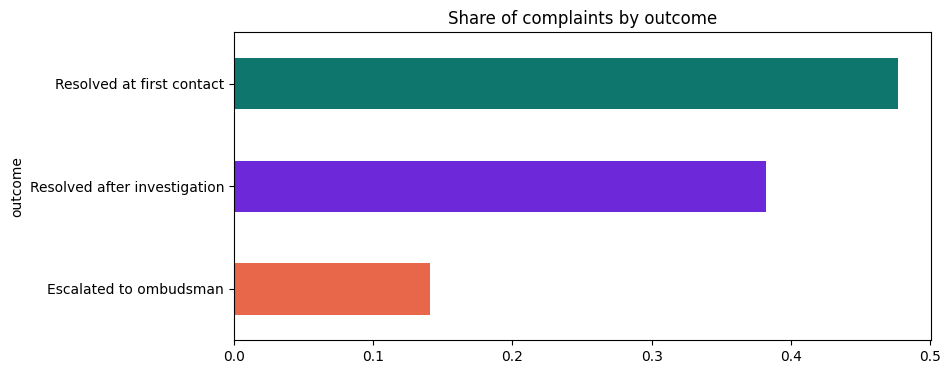

Baseline accuracy (always predict the majority class): 47.7%


In [13]:
outcome_share = df["outcome"].value_counts(normalize=True).round(3).reindex(OUTCOME_ORDER)
print(pd.concat([df["outcome"].value_counts().reindex(OUTCOME_ORDER), outcome_share], axis=1, keys=["count", "share"]))

ax = outcome_share.plot.barh(color=[OUTCOME_COLORS[o] for o in OUTCOME_ORDER], title="Share of complaints by outcome")
ax.invert_yaxis()
plt.show()
print(f"Baseline accuracy (always predict the majority class): {outcome_share.max():.1%}")

### 4.2 Distribution of the numeric features

Histograms show the shape of each variable: symmetric, skewed, bounded, with isolated values far away.

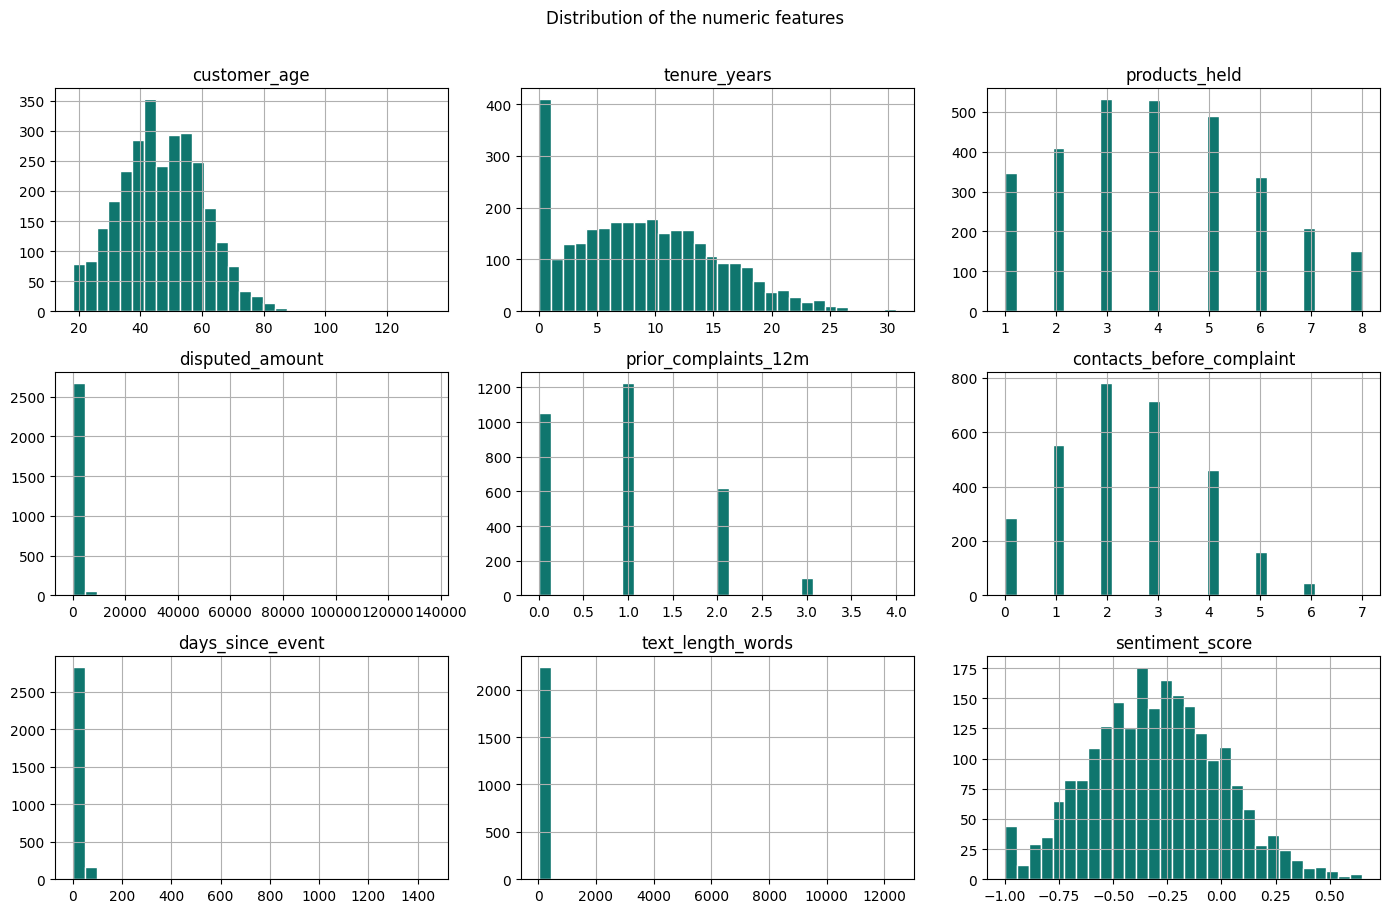

In [14]:
numeric_cols = ["customer_age", "tenure_years", "products_held", "disputed_amount", "prior_complaints_12m",
                "contacts_before_complaint", "days_since_event", "text_length_words", "sentiment_score"]

df[numeric_cols].hist(bins=30, figsize=(14, 9), color=TEAL, edgecolor="white")
plt.suptitle("Distribution of the numeric features", y=1.01)
plt.tight_layout()
plt.show()

`disputed_amount` is heavily skewed: most complaints concern a few hundred euros, a few concern tens of
thousands. On a logarithmic scale the shape becomes readable, and this is also the scale we will use for
modelling and for outlier detection on this column.

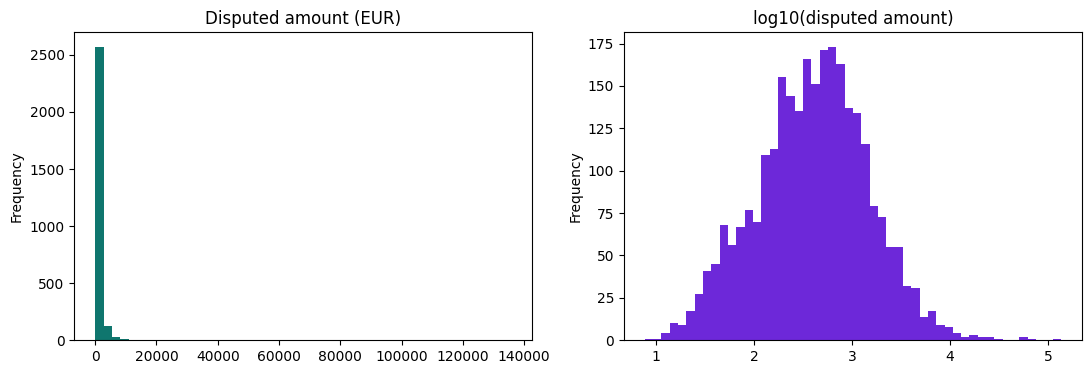

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["disputed_amount"].plot.hist(bins=50, ax=axes[0], color=TEAL, title="Disputed amount (EUR)")
np.log10(df["disputed_amount"]).plot.hist(bins=50, ax=axes[1], color=PURPLE, title="log10(disputed amount)")
plt.show()

The interactive version lets us overlay the three outcomes: the escalated complaints sit visibly to the
right (larger amounts) and to the left of the sentiment scale (more negative tone). Click a legend entry to
hide or show a class.

In [18]:
fig = px.histogram(df.assign(amount_log10=np.log10(df["disputed_amount"])), x="amount_log10", color="outcome",
                   nbins=60, barmode="overlay", opacity=0.65, category_orders={"outcome": OUTCOME_ORDER},
                   color_discrete_map=OUTCOME_COLORS, title="log10(disputed amount) by outcome")
fig.show()

fig = px.histogram(df, x="sentiment_score", color="outcome", nbins=40, barmode="overlay", opacity=0.65,
                   category_orders={"outcome": OUTCOME_ORDER}, color_discrete_map=OUTCOME_COLORS,
                   title="Sentiment score by outcome")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### 4.3 Categorical features and their relationship with the outcome

Bar charts of the counts first, then the share of each outcome within each category (`crosstab` with
`normalize="index"`). The second view is the one that carries business meaning.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["product", "channel", "customer_segment"]):
    df[col].value_counts().plot.bar(ax=ax, color=TEAL, title=col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
share_by_channel = pd.crosstab(df["channel"], df["outcome"], normalize="index")[OUTCOME_ORDER].round(3)
share_by_channel.sort_values("Escalated to ombudsman")

In [ ]:
share_by_product = pd.crosstab(df["product"], df["outcome"], normalize="index")[OUTCOME_ORDER].round(3)
share_by_product.sort_values("Escalated to ombudsman")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
share_by_channel.sort_values("Escalated to ombudsman").plot.barh(stacked=True, ax=axes[0], title="Outcome share by channel",
                                                                  color=[OUTCOME_COLORS[o] for o in OUTCOME_ORDER])
share_by_product.sort_values("Escalated to ombudsman").plot.barh(stacked=True, ax=axes[1], title="Outcome share by product",
                                                                  color=[OUTCOME_COLORS[o] for o in OUTCOME_ORDER], legend=False)
axes[0].legend(bbox_to_anchor=(1.0, -0.15), ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
fig = px.histogram(df, x="channel", color="outcome", barnorm="percent", category_orders={"outcome": OUTCOME_ORDER},
                   color_discrete_map=OUTCOME_COLORS, title="Outcome share by channel (%)")
fig.show()

> **Business insight.** Social-media complaints escalate about a third of the time, mobile-app complaints less
> than one in ten. Investment and mortgage complaints escalate twice as often as current-account ones. The
> channel and the product are known the second a complaint arrives: a triage rule could start from here even
> without a model.
>
> **Risk.** A high escalation rate on social media may also mean that the *public* nature of the channel
> pushes the bank to settle. Correlation is not a cause: the model will learn the pattern, not the reason.

### 4.4 Complaints over time

A time series of monthly volumes is the simplest "sensor" a complaints department has. We aggregate the
dates by month with `to_period("M")` and draw a line plot.

In [ ]:
monthly = df.groupby(df["complaint_date"].dt.to_period("M")).size()
monthly.index = monthly.index.to_timestamp()

ax = monthly.plot.line(marker="o", color=TEAL, title="Complaints per month")
ax.set_ylabel("complaints")
ax.set_xlabel("")
plt.show()

February 2026 is more than twice the usual volume. Splitting the series by channel shows where the surge comes
from.

In [ ]:
monthly_by_channel = df.groupby([df["complaint_date"].dt.to_period("M"), "channel"]).size().unstack(fill_value=0)
monthly_by_channel.index = monthly_by_channel.index.to_timestamp()

ax = monthly_by_channel.plot.line(figsize=(11, 4), title="Complaints per month by channel")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1.01, 1))
plt.show()

In [ ]:
long_format = monthly_by_channel.reset_index().melt(id_vars="complaint_date", var_name="channel", value_name="complaints")
fig = px.line(long_format, x="complaint_date", y="complaints", color="channel", markers=True,
              title="Complaints per month by channel (interactive)")
fig.show()

In [ ]:
# zoom on the surge: daily complaints through the mobile app around February 2026
window = df[(df["channel"] == "Mobile app") & df["complaint_date"].between("2026-01-15", "2026-03-15")]
daily = window.groupby("complaint_date").size()

ax = daily.plot.line(marker="o", color=CORAL, title="Daily mobile-app complaints, Jan 15 - Mar 15, 2026")
ax.set_xlabel("")
plt.show()
window["product"].value_counts()

> **Business insight.** Between 3 and 14 February 2026 the mobile app generated a burst of current-account
> complaints: an operational incident (an outage, a duplicated-payment bug). Volume monitoring would have
> raised the alarm on day two.
>
> **Risk for the model.** Those 200 complaints are atypical (small amounts, quickly resolved). A model trained
> on a period with an incident learns the incident too. When we deploy, we must watch for **drift**: the
> data the model sees in production may not look like the data it was trained on.

### 4.5 Relationships between features

Box plots by outcome show which numeric features separate the classes; the correlation matrix and the scatter
matrix show how the features move together.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
df.assign(amount_log10=np.log10(df["disputed_amount"])).boxplot(column="amount_log10", by="outcome", ax=axes[0])
df.boxplot(column="sentiment_score", by="outcome", ax=axes[1])
df.boxplot(column="contacts_before_complaint", by="outcome", ax=axes[2])
for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15, labelsize=8)
plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
fig = px.box(df, x="outcome", y="disputed_amount", color="outcome", log_y=True, hover_data=["complaint_id", "product", "customer_segment"],
             category_orders={"outcome": OUTCOME_ORDER}, color_discrete_map=OUTCOME_COLORS,
             title="Disputed amount by outcome (log scale)")
fig.show()

**Correlation matrix.** We use the logarithm of the amount, otherwise its long tail would hide the linear
relationships. Values close to +1 or −1 indicate features that move together.

In [ ]:
num = df[numeric_cols].copy()
num["disputed_amount"] = np.log10(num["disputed_amount"])
num = num.rename(columns={"disputed_amount": "disputed_amount_log10"})

corr = num.corr().round(2)
corr

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, corr.values[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(image, shrink=0.8)
ax.set_title("Correlation matrix (Pearson)")
plt.show()

In [ ]:
fig = px.imshow(corr, text_auto=True, color_continuous_scale="RdBu_r", zmin=-1, zmax=1, aspect="auto",
                title="Correlation matrix (interactive)")
fig.update_layout(height=600)
fig.show()

> **Business insight.** A "severity" cluster stands out: larger amounts, more negative sentiment, more contacts
> before the complaint and more previous complaints move together. They are symptoms of the same thing: a
> customer with a serious, unresolved problem. Age, tenure and number of products form a second, unrelated
> cluster.
>
> **Something does not add up.** `text_length_words` and `days_since_event` are almost uncorrelated with the
> rest of the severity cluster, although the box plots by outcome suggested otherwise. Pearson's correlation is
> fragile: a handful of extreme values can flatten it. A quick check with the rank-based Spearman correlation,
> which is immune to extreme values, tells a different story. We will come back to this in section 6.

**Scatter plots and the scatter matrix.** Two variables at a time. With the interactive version we can
hover on any point to read its `complaint_id`, which will be useful in the outlier section.

In [ ]:
# Spearman correlation works on ranks, so a few extreme values cannot distort it
num.corr(method="spearman").round(2).loc[["text_length_words", "days_since_event"], ["disputed_amount_log10", "sentiment_score", "contacts_before_complaint", "prior_complaints_12m"]]

In [ ]:
ax = df.plot.scatter(x="customer_age", y="tenure_years", alpha=0.35, color=TEAL, title="Tenure vs age")
plt.show()

fig = px.scatter(df, x="disputed_amount", y="sentiment_score", color="outcome", log_x=True, opacity=0.6,
                 hover_data=["complaint_id", "product", "channel"], category_orders={"outcome": OUTCOME_ORDER},
                 color_discrete_map=OUTCOME_COLORS, title="Sentiment vs disputed amount, by outcome")
fig.show()

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(num[["customer_age", "tenure_years", "disputed_amount_log10", "text_length_words", "sentiment_score"]],
               figsize=(12, 12), alpha=0.3, diagonal="hist", color=TEAL)
plt.suptitle("Scatter matrix of five numeric features", y=0.92)
plt.show()

In [ ]:
fig = px.scatter_matrix(num.join(df[["outcome", "complaint_id"]]),
                        dimensions=["disputed_amount_log10", "text_length_words", "sentiment_score", "contacts_before_complaint"],
                        color="outcome", opacity=0.5, hover_data=["complaint_id"],
                        category_orders={"outcome": OUTCOME_ORDER}, color_discrete_map=OUTCOME_COLORS,
                        title="Scatter matrix, coloured by outcome (interactive)")
fig.update_traces(diagonal_visible=False, marker=dict(size=3))
fig.update_layout(height=750)
fig.show()

## 5. Missing values

### 5.1 How much is missing, and where

`isna()` returns True for every missing cell. Summing it by column gives the count; taking the mean gives the
share.

In [ ]:
missing = pd.concat([df.isna().sum(), df.isna().mean().round(3)], axis=1, keys=["missing", "share"])
missing[missing["missing"] > 0]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 2.2]})
missing.loc[missing["missing"] > 0, "share"].sort_values().plot.barh(ax=axes[0], color=CORAL, title="Share of missing values")

# "missingness map": one column per row of the dataset, one line per column; dark = missing
cols_with_missing = missing.index[missing["missing"] > 0]
axes[1].imshow(df[cols_with_missing].isna().T, aspect="auto", cmap="Greys", interpolation="nearest")
axes[1].set_yticks(range(len(cols_with_missing)))
axes[1].set_yticklabels(cols_with_missing)
axes[1].set_xlabel("row (ordered by complaint date)")
axes[1].set_title("Where the missing values are")
plt.tight_layout()
plt.show()

Notice that `complaint_excerpt`, `text_length_words` and `sentiment_score` are missing on the *same* rows: the three
columns come from the same source, the complaint text. When there is no text, all three are blank.

### 5.2 Why values are missing: three mechanisms

![](missing_mechanisms.png)

The statistical literature distinguishes three mechanisms, and the distinction is practical, because it decides
which handling strategies are safe.

| Mechanism | Definition | Example in this dataset | Consequence |
|---|---|---|---|
| **MCAR** — missing completely at random | the probability of a blank does not depend on anything, observed or not | `customer_age` blank because of random data-entry glitches | dropping or imputing the rows is unbiased; we only lose some information |
| **MAR** — missing at random | the probability of a blank depends on *other observed* columns | text features blank mostly for branch and phone complaints, which have no written text | imputation can use the observed columns; a "text available" flag preserves the information |
| **MNAR** — missing not at random | the probability of a blank depends on the *missing value itself* | `disputed_amount` blank more often when the amount is large (large claims go to a separate legal workflow) | any imputation is biased; the blank is itself informative and should become a feature |

We cannot prove the mechanism from the data alone, but we can look for evidence.

In [ ]:
# Evidence of MCAR: the share of blank ages is roughly the same in every channel and every segment
print("Missing customer_age by channel:")
print(df["customer_age"].isna().groupby(df["channel"]).mean().round(3), "\n")
print("Missing customer_age by segment:")
print(df["customer_age"].isna().groupby(df["customer_segment"]).mean().round(3))

In [ ]:
# Evidence of MAR: blank sentiment depends on an observed column, the channel
df["sentiment_score"].isna().groupby(df["channel"]).mean().round(3).sort_values()

In [ ]:
# Evidence of MNAR: we cannot see the blank amounts, but complaints with a blank amount escalate far more often
# and receive a much higher compensation at closure - a sign that these were the large claims
print(df.groupby(df["disputed_amount"].isna())["outcome"].value_counts(normalize=True).round(3).unstack()[OUTCOME_ORDER], "\n")
print("Median compensation, by whether the amount is blank:")
print(df.groupby(df["disputed_amount"].isna())["compensation_eur"].median())

> **Business insight.** A blank field is not the absence of information. Here the blank amount is one of the
> best predictors of escalation, because the *process* that leaves it blank (the legal workflow) is itself
> the process that handles the serious cases. Before "fixing" missing data, ask the people who run the process
> why the field is empty.

### 5.3 Handling strategies

Four strategies, from the simplest to the most sophisticated. We try each on our data to see its effect.

**a) Delete the rows** (`dropna`). Simple and honest, but expensive: with several columns affected we lose
a large share of the data, and if the mechanism is not MCAR we also bias what remains.

In [ ]:
print("Rows with at least one missing value:", df.isna().any(axis=1).sum(), "of", len(df))
print("Rows left after dropna():", len(df.dropna()))

**b) Fill with a constant summary**: the mean or the median for numeric columns, the most frequent value
(mode) for categorical ones. The median is preferred for skewed columns such as the amount, where the mean is
pulled up by the long tail.

In [ ]:
print(f"disputed_amount   mean = {df['disputed_amount'].mean():8.1f}   median = {df['disputed_amount'].median():8.1f}")
print(f"customer_age      mean = {df['customer_age'].mean():8.1f}   median = {df['customer_age'].median():8.1f}")
print(f"sentiment_score   mean = {df['sentiment_score'].mean():8.2f}   median = {df['sentiment_score'].median():8.2f}")
print("customer_segment  mode =", df["customer_segment"].mode()[0])

Filling with a constant has a visible side effect: it creates a spike in the distribution at the filled value.
For the text features this spike would contain 25% of the rows.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
df["sentiment_score"].plot.hist(bins=40, ax=axes[0], color=TEAL, title="Sentiment score - as recorded (blanks ignored)")
df["sentiment_score"].fillna(df["sentiment_score"].median()).plot.hist(bins=40, ax=axes[1], color=CORAL, title="After filling blanks with the median")
plt.show()

**c) Impute with a model.** Predict the missing value from the other columns. For the age we can train a small
regression model on the rows where the age is known, using tenure and number of products as inputs, and use it
to fill the rows where the age is blank. The imputed values are then spread realistically instead of piling up
on one number.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

known = df["customer_age"].notna()
age_model = RandomForestRegressor(n_estimators=200, random_state=42)
age_model.fit(df.loc[known, ["tenure_years", "products_held"]], df.loc[known, "customer_age"])

age_from_model = age_model.predict(df.loc[~known, ["tenure_years", "products_held"]])

fig, ax = plt.subplots(figsize=(9, 4))
df.loc[known, "customer_age"].plot.hist(bins=30, ax=ax, color=TEAL, alpha=0.5, density=True, label="recorded ages")
pd.Series(age_from_model).plot.hist(bins=30, ax=ax, color=PURPLE, alpha=0.6, density=True, label="ages imputed by the model")
ax.axvline(df["customer_age"].median(), color=CORAL, linestyle="--", label="median (constant imputation)")
ax.legend()
ax.set_title("Model-based imputation spreads the imputed ages instead of piling them on the median")
plt.show()

**d) Add a missing indicator.** A new 0/1 column that records *whether* the value was missing. It costs
nothing and, for MAR and MNAR columns, it keeps the information carried by the blank itself. We will use it for
the amount (MNAR) and for the text features (MAR).

### 5.4 Our decisions

| Column | Mechanism | Decision |
|---|---|---|
| `customer_age` | MCAR | median (simple; the model-based version is an option if age matters) |
| `sentiment_score`, `text_length_words` | MAR | median **plus** a `text_available` indicator |
| `disputed_amount` | MNAR | median **plus** an `amount_missing` indicator |
| `customer_segment` | text "unknown" | its own category, `Unknown` |
| `complaint_excerpt` | MAR | not a feature of the model: its information enters through `sentiment_score` |

We apply the decisions in section 7, *after* the outlier analysis: an extreme value would distort the medians
we impute with.

## 6. Outliers

![](outlier_types.png)

An outlier is an observation far from the others. The interesting question is *far in which sense*:

- **univariate**: far on one column alone (box plot, z-score);
- **bivariate**: normal on each column, but an impossible or unusual *pair* (scatter plot, scatter matrix);
- **multivariate**: normal on every column and every pair, but an implausible *combination* of many columns
  (Mahalanobis distance).

And the second question is *what to do with it*: an error to correct or remove, a rare but genuine case to
keep, or a signal to investigate (fraud, a broken process).

### 6.1 Box plots and the 1.5 × IQR rule

The box spans the first to the third quartile (the interquartile range, IQR); the whiskers extend 1.5 × IQR
beyond the box; anything further is drawn as a point.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
for ax, col in zip(axes, ["disputed_amount", "customer_age", "text_length_words", "days_since_event"]):
    df.boxplot(column=col, ax=ax)
plt.suptitle("Box plots of four numeric features", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
col = "disputed_amount"
q1, q3 = df[col].quantile([0.25, 0.75])
upper_whisker = q3 + 1.5 * (q3 - q1)
print(f"{col}: Q1 = {q1:.0f}, Q3 = {q3:.0f}, IQR = {q3 - q1:.0f}, upper whisker = {upper_whisker:.0f}")
print("Rows above the upper whisker:", (df[col] > upper_whisker).sum())

Two hundred and fifty "outliers" is not a list anyone can investigate, and most of them are legitimate large
claims from private-banking and investment customers. On a skewed variable the 1.5 × IQR rule must be applied
on the log scale; then the list becomes short.

In [ ]:
amount_log10 = np.log10(df["disputed_amount"])
q1, q3 = amount_log10.quantile([0.25, 0.75])
upper_log = q3 + 1.5 * (q3 - q1)
print("Rows above the upper whisker on the log scale:", (amount_log10 > upper_log).sum())

df.loc[amount_log10 > upper_log, ["complaint_id", "customer_segment", "product", "disputed_amount", "outcome"]].sort_values("disputed_amount", ascending=False)

Read the amounts: five of them end in `.00` and belong to retail customers. They are exactly 100 times a
plausible amount: cents keyed as euros. The others are large but credible (mortgages, investments,
private-banking customers). The text of the complaint settles the doubt: the customer writes the true amount.

In [ ]:
no_cents = (df["disputed_amount"] >= 10000) & ((df["disputed_amount"] * 100).round() % 100 == 0)
df.loc[no_cents, ["complaint_id", "customer_segment", "disputed_amount", "complaint_excerpt"]]

The interactive box plot by segment makes the same point: hover on the extreme points to read the
`complaint_id`.

In [ ]:
fig = px.box(df.dropna(subset=["customer_segment"]), x="customer_segment", y="disputed_amount", log_y=True, color="customer_segment",
             hover_data=["complaint_id", "product"], title="Disputed amount by segment (log scale) - hover on the extreme points")
fig.show()

### 6.2 The z-score

The z-score measures how many standard deviations a value is from the column mean. A common rule flags
|z| > 3. It is quick and works on every numeric column at once, with two caveats: it assumes a roughly
symmetric distribution (use the log for the amount), and an extreme value inflates the standard deviation and
can hide, or "mask", other outliers.

In [ ]:
z = (num - num.mean()) / num.std()           # `num` already has the amount on the log10 scale
z_flags = z.abs() > 3
print("Rows with |z| > 3, per column:")
print(z_flags.sum())

In [ ]:
for col in ["customer_age", "text_length_words", "days_since_event", "disputed_amount_log10"]:
    rows = df.loc[z_flags[col], ["complaint_id", col.replace("_log10", "")]]
    print(f"\n{col}: {len(rows)} rows")
    print(rows.to_string(index=False))

> **Reading the list.** A flag is a question, not a verdict. Ages of 119–134 are impossible, ages of 88–92 are
> simply old customers. A complaint of 12,400 words is a pasted document; an event four years old may be
> genuine but is worth a look. On the log scale the z-score finds the same amounts as the box plot; on the *raw*
> amount it would have flagged only the very largest values, so the transformation matters more than the
> threshold. The flags on the count columns (contacts, prior complaints) are the natural tail of a discrete
> variable and would be released after a glance.

### 6.3 Scatter plots: outliers that live in a pair of columns

Age and tenure are individually well-behaved. Plotting one against the other reveals a physical constraint:
nobody can have been a customer for longer than their adult life, so every point must lie below the line
`tenure = age − 18`.

In [ ]:
ax = df.plot.scatter(x="customer_age", y="tenure_years", alpha=0.35, color=TEAL, figsize=(9, 5), title="Tenure vs age")
ax.plot([18, 95], [0, 77], color=CORAL, linewidth=2, label="tenure = age - 18 (physical limit)")
ax.legend()
plt.show()

In [ ]:
fig = px.scatter(df, x="customer_age", y="tenure_years", opacity=0.5, hover_data=["complaint_id", "products_held"],
                 title="Tenure vs age (interactive) - hover on the points above the diagonal")
fig.show()

In [ ]:
impossible_tenure = df["tenure_years"] > df["customer_age"] - 18
print("Rows with tenure longer than adult life:", impossible_tenure.sum())
df.loc[impossible_tenure, ["complaint_id", "customer_age", "tenure_years", "products_held"]]

### 6.4 The scatter matrix: many pairs at once

With nine numeric columns there are 36 pairs. The scatter matrix draws them all; we look for points that sit
away from the cloud in *some* panel. Here a small group of customers with a few months of tenure and 7–8
products stands out in the `tenure_years` / `products_held` panel: either a data-entry error or a customer
migrated from another bank, both worth checking.

In [ ]:
scatter_matrix(df[["customer_age", "tenure_years", "products_held", "days_since_event"]],
               figsize=(11, 11), alpha=0.3, diagonal="hist", color=TEAL)
plt.suptitle("Scatter matrix: look for points away from every cloud", y=0.92)
plt.show()

In [ ]:
fig = px.scatter_matrix(df, dimensions=["customer_age", "tenure_years", "products_held", "days_since_event"],
                        opacity=0.4, hover_data=["complaint_id"], title="Scatter matrix (interactive)")
fig.update_traces(diagonal_visible=False, marker=dict(size=3, color=TEAL))
fig.update_layout(height=700)
fig.show()

In [ ]:
new_with_many_products = (df["tenure_years"] < 1) & (df["products_held"] >= 7)
print("New customers with 7 or more products:", new_with_many_products.sum())
df.loc[new_with_many_products, ["complaint_id", "customer_age", "tenure_years", "products_held", "customer_segment"]]

### 6.5 Removing the gross errors before going further

We collect the records identified so far that are *errors* rather than genuine cases, and set them aside.
In a real project we would go back to the source system and correct them; here we simply exclude them. The
next technique, the Mahalanobis distance, is sensitive to gross errors, so this step comes first.

In [ ]:
is_error = (
    (df["customer_age"] > 100)                                              # impossible age
    | (df["tenure_years"] > df["customer_age"] - 18)                        # tenure longer than adult life
    | ((df["tenure_years"] < 1) & (df["products_held"] >= 7))               # months of tenure, 7-8 products
    | (df["text_length_words"] > 3000)                                      # pasted document
    | (df["days_since_event"] > 365)                                        # event older than a year
    | ((df["disputed_amount"] >= 10000) & ((df["disputed_amount"] * 100).round() % 100 == 0))   # cents keyed as euros
)
print("Rows set aside as errors:", is_error.sum())
df_clean = df[~is_error].reset_index(drop=True)
print("Rows kept:", len(df_clean))

Back to the puzzle of section 4.5: with the three extreme values gone (a 12,400-word text, a 9,800-word text,
a four-year-old event), the Pearson correlations of `text_length_words` and `days_since_event` with the severity
cluster reappear. Three cells out of 27,000 were enough to hide them.

In [ ]:
severity_cols = ["disputed_amount", "text_length_words", "sentiment_score", "days_since_event", "contacts_before_complaint", "prior_complaints_12m"]
before = df[severity_cols].assign(disputed_amount=np.log10(df["disputed_amount"])).corr().round(2)
after = df_clean[severity_cols].assign(disputed_amount=np.log10(df_clean["disputed_amount"])).corr().round(2)

print("Pearson correlation BEFORE removing the errors:")
print(before.loc[["text_length_words", "days_since_event"]], "\n")
print("Pearson correlation AFTER removing the errors:")
print(after.loc[["text_length_words", "days_since_event"]])

### 6.6 The Mahalanobis distance: outliers hidden in the combination

The z-score measures distance from the mean *one column at a time*. The **Mahalanobis distance** measures
the distance of a whole row from the centre of the data, taking the correlations between columns into account.

For a row `x`, with `μ` the vector of column means and `S` the covariance matrix:

$$D^2 = (x - \mu)^\top S^{-1} (x - \mu)$$

Intuitively: along a direction in which the data are spread out, a deviation counts little; along a direction
in which the data are tightly correlated, the same deviation counts a lot. A customer with a large disputed
amount, a very short and *positive* complaint text and no previous contact is not extreme on any single column,
but that combination almost never happens.

If the columns were normally distributed, `D²` would follow a chi-square distribution with as many degrees of
freedom as there are columns, which gives us a threshold: we flag rows above the 99.9% quantile.

We compute it on the eight numeric intake features (amount on the log scale), using only the rows where all
eight are present.

In [ ]:
md_cols = ["customer_age", "tenure_years", "disputed_amount", "text_length_words", "sentiment_score",
           "days_since_event", "contacts_before_complaint", "prior_complaints_12m"]

X = df_clean[md_cols].copy()
X["disputed_amount"] = np.log1p(X["disputed_amount"])
X = X.dropna()                                            # complete cases only

mean_vector = X.mean().values
cov_inverse = np.linalg.inv(np.cov(X.values, rowvar=False))
diff = X.values - mean_vector
d2 = np.sum((diff @ cov_inverse) * diff, axis=1)          # one D^2 per row

threshold = chi2.ppf(0.999, df=len(md_cols))
mahalanobis = pd.DataFrame({"complaint_id": df_clean.loc[X.index, "complaint_id"], "mahalanobis_d2": d2}, index=X.index)
mahalanobis["flag"] = np.where(mahalanobis["mahalanobis_d2"] > threshold, "multivariate outlier", "normal")

print(f"Rows analysed: {len(X)}   threshold (99.9% chi-square, {len(md_cols)} features): {threshold:.1f}")
print(mahalanobis["flag"].value_counts())

In [ ]:
fig = px.scatter(mahalanobis.reset_index(), x="index", y="mahalanobis_d2", color="flag",
                 color_discrete_map={"normal": TEAL, "multivariate outlier": CORAL},
                 hover_data=["complaint_id"], opacity=0.6, title="Mahalanobis distance² of every complaint (interactive)")
fig.add_hline(y=threshold, line_dash="dash", line_color=GREY, annotation_text="99.9% threshold")
fig.update_layout(xaxis_title="row", yaxis_title="D²")
fig.show()

Are these rows visible with the tools we used before? We check their z-scores: every value is within about two
standard deviations, so no univariate rule catches them.

In [ ]:
flagged_rows = mahalanobis.index[mahalanobis["flag"] == "multivariate outlier"]
z_clean = (X - X.mean()) / X.std()

report = df_clean.loc[flagged_rows, ["complaint_id"] + md_cols].copy()
report["max |z|"] = z_clean.loc[flagged_rows].abs().max(axis=1).round(2)
report["D2"] = mahalanobis.loc[flagged_rows, "mahalanobis_d2"].round(1)
report.sort_values("D2", ascending=False)

And in the scatter matrix they hide inside the clouds: no single panel isolates them. Only the combination of
eight columns does.

In [ ]:
plot_data = X.join(mahalanobis["flag"]).rename(columns={"disputed_amount": "disputed_amount_log"})
plot_data = plot_data.sort_values("flag")               # draw the outliers last, on top
fig = px.scatter_matrix(plot_data, dimensions=["disputed_amount_log", "text_length_words", "sentiment_score", "contacts_before_complaint"],
                        color="flag", color_discrete_map={"normal": TEAL, "multivariate outlier": CORAL},
                        opacity=0.5, title="The multivariate outliers sit inside every two-dimensional cloud")
fig.update_traces(diagonal_visible=False, marker=dict(size=4))
fig.update_layout(height=750)
fig.show()

> **Business reading.** Look at the flagged rows: a large claim described in a few polite words with no
> previous contact, or a very old, very negative complaint about a trivial amount. Nothing is *wrong* in these
> records; the combination is unusual. In a complaints department these are the cases to hand to a senior
> analyst: possible mis-keyed records, possible fraud, or simply the kind of atypical case a model will get wrong.
>
> **Decision.** We keep these rows for modelling (the values are plausible) and pass the list to the data-quality
> team for review.

## 7. Cleaning decisions and feature preparation

We now apply the decisions of sections 5 and 6 and build the table the models will learn from.

*A simplification to be aware of:* we compute the medians on the whole dataset before splitting it into
training and test sets. In a production pipeline the imputation values are computed on the training set only,
so that nothing from the test set leaks into the model. For a demo the difference is negligible.

In [ ]:
data = df_clean.copy()

# 1. missing indicators, created BEFORE imputing (otherwise the information is gone)
data["amount_missing"] = data["disputed_amount"].isna().astype(int)
data["text_available"] = data["sentiment_score"].notna().astype(int)

# 2. imputation with the median; the values are stored so that we can apply them to new complaints later
fill_values = {"customer_age": data["customer_age"].median(),
               "disputed_amount": data["disputed_amount"].median(),
               "sentiment_score": data["sentiment_score"].median(),
               "text_length_words": data["text_length_words"].median()}
data = data.fillna(fill_values)
data["customer_segment"] = data["customer_segment"].fillna("Unknown")

# 3. the amount on the log scale
data["disputed_amount_log"] = np.log1p(data["disputed_amount"])

print("Imputation values:", {k: round(v, 2) for k, v in fill_values.items()})
print("Missing cells left:", data.isna().sum().sum())

**Features and target.** The identifier and the date are not features (the model must not learn that
"complaint number 1,234 escalated"). The categorical columns are converted to 0/1 columns with
`get_dummies`, a technique called one-hot encoding: `channel` becomes `channel_Branch`, `channel_Email`, and so on.

In [ ]:
categorical_cols = ["product", "channel", "customer_segment"]
feature_frame = data.drop(columns=["complaint_id", "complaint_date", "outcome", "compensation_eur", "disputed_amount", "complaint_excerpt"])

X_all = pd.get_dummies(feature_frame, columns=categorical_cols, dtype=int)
y_all = data["outcome"]

print("Feature matrix:", X_all.shape)
X_all.head()

### The leakage trap

Before we drop it, let us see what happens if `compensation_eur` is left among the features. We fit a random
forest with and without it. (The functions used here are explained in section 8.)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_leaky = X_all.copy()
X_leaky["compensation_eur"] = data["compensation_eur"]

Xtr, Xte, ytr, yte = train_test_split(X_leaky, y_all, test_size=0.2, random_state=42, stratify=y_all)
with_leak = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xtr, ytr).score(Xte, yte)
without_leak = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xtr.drop(columns="compensation_eur"), ytr).score(Xte.drop(columns="compensation_eur"), yte)

print(f"Test accuracy WITH compensation_eur:    {with_leak:.3f}")
print(f"Test accuracy WITHOUT compensation_eur: {without_leak:.3f}")

> **Risk.** The compensation is decided when the complaint is closed: it is a consequence of the outcome, not a
> cause. A model that uses it is brilliant on historical data and blind on the day a new complaint arrives,
> because the field is empty. This is **data leakage**, and the symptom is always the same: an accuracy that is
> too good to be true. Whenever a model looks surprisingly strong, the first question is *"would every
> feature really be known at prediction time?"*. That is why the data dictionary has a column "known at intake".

## 8. Three classification models

We compare three algorithms that analysts meet most often:

- **Logistic regression** — a linear model; the coefficients tell how each feature pushes towards each class.
  Needs the features on a comparable scale, so we standardise them first.
- **Decision tree** — a sequence of yes/no questions; can be drawn and read as a set of business rules.
- **Random forest** — hundreds of decision trees, each trained on a random sample of rows and columns, that
  vote. Usually more accurate than a single tree, at the price of readability.

### 8.1 Train/test split

We keep 20% of the complaints aside. The model never sees them during training; they simulate the "new
complaints" on which we will be judged. `stratify` keeps the three outcomes in the same proportions in both sets.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
print("Training rows:", len(X_train), "  Test rows:", len(X_test))
print("\nBaseline accuracy on the test set (always predict the majority class):", round(y_test.value_counts(normalize=True).max(), 3))

### 8.2 Fit the three models and measure accuracy on the test set

**Accuracy** is the share of complaints whose outcome the model predicts correctly. It is the simplest
metric and the easiest to explain, and it has a known blind spot: on imbalanced classes it can be high while
the smallest class is mostly missed. The confusion matrix will show us that.

In [ ]:
models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Decision tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random forest": RandomForestClassifier(n_estimators=300, random_state=42),
}

test_accuracy = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    test_accuracy[name] = accuracy_score(y_test, model.predict(X_test))

pd.Series(test_accuracy, name="test accuracy").round(3)

### 8.3 The confusion matrix

Rows are the true outcomes, columns the predicted ones. The diagonal holds the correct predictions. The
cell that costs the bank most is **true "Escalated", predicted "First contact"**: a complaint that will go to the
ombudsman, put in the fast lane and handled by the front line.

In [ ]:
short_labels = ["First contact", "Investigation", "Escalated"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, labels=OUTCOME_ORDER, display_labels=short_labels,
                                          ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}  (accuracy {test_accuracy[name]:.3f})")
plt.tight_layout()
plt.show()

> **Business reading.** All three models recognise most first-contact cases and a fair share of the
> investigations. The escalations are the hard class: about half of them are predicted as "investigation",
> which is still a useful signal (they leave the fast lane), while a minority are predicted as first-contact
> resolutions and would be missed by the triage. Accuracy alone would not have told us this.
>
> Note also that the simplest model, logistic regression, is as accurate as the random forest: complexity is
> not accuracy. On tabular data with a few strong, roughly linear drivers, a linear model is hard to beat, and
> it is far easier to explain to a regulator.

### 8.4 Cross-validation

A single train/test split depends on luck: a different random split gives a slightly different accuracy.
**k-fold cross-validation** splits the training set into k parts (here 5), trains on four and tests on the
fifth, five times, and reports the five accuracies. The mean is a more reliable estimate and the spread tells
us how much the result depends on the split.

In [ ]:
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name:20s} CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}   folds: {np.round(scores, 3)}")

### 8.5 Hyper-parameter tuning with GridSearchCV

Each algorithm has settings that are not learned from the data but chosen by us: the depth of a tree, the
number of trees in a forest, the minimum number of complaints in a leaf. These are **hyper-parameters**.
`GridSearchCV` tries every combination in a grid, evaluates each with cross-validation, and keeps the best.

We tune the random forest (the model with most settings to choose) and the decision tree (the most readable
one). Tuning usually buys a few points of accuracy, rarely a miracle: the quality of the features matters more.

In [ ]:
forest_grid = {"n_estimators": [100, 200], "max_depth": [6, 12, None], "min_samples_leaf": [1, 10]}
forest_search = GridSearchCV(RandomForestClassifier(random_state=42), forest_grid, cv=5, n_jobs=-1)
forest_search.fit(X_train, y_train)

print("Best parameters:", forest_search.best_params_)
print("Best cross-validated accuracy:", round(forest_search.best_score_, 3))
best_forest = forest_search.best_estimator_
print("Test accuracy of the tuned random forest:", round(best_forest.score(X_test, y_test), 3))

In [ ]:
# all the combinations tried, best first
search_results = pd.DataFrame(forest_search.cv_results_)[["param_n_estimators", "param_max_depth", "param_min_samples_leaf", "mean_test_score", "std_test_score"]]
search_results.sort_values("mean_test_score", ascending=False).round(3).head(8)

In [ ]:
tree_grid = {"max_depth": [3, 5, 8, 12], "min_samples_leaf": [1, 10, 30]}
tree_search = GridSearchCV(DecisionTreeClassifier(random_state=42), tree_grid, cv=5)
tree_search.fit(X_train, y_train)

print("Best parameters:", tree_search.best_params_)
print("Best cross-validated accuracy:", round(tree_search.best_score_, 3))
best_tree = tree_search.best_estimator_
print("Test accuracy of the tuned decision tree:", round(best_tree.score(X_test, y_test), 3))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(best_forest, X_test, y_test, labels=OUTCOME_ORDER, display_labels=short_labels, ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Tuned random forest")
ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test, labels=OUTCOME_ORDER, display_labels=short_labels, ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Tuned decision tree")
plt.tight_layout()
plt.show()

### 8.6 What drives the prediction?

The random forest can rank the features by how much they contribute to its decisions (**feature importance**).
It confirms the EDA: the severity cluster and the channel do the work.

In [ ]:
importance = pd.Series(best_forest.feature_importances_, index=X_train.columns).sort_values(ascending=False)
ax = importance.head(12).sort_values().plot.barh(color=TEAL, figsize=(9, 5), title="Top 12 features of the tuned random forest")
ax.set_xlabel("importance")
plt.show()

A shallow decision tree can be drawn and read as a triage rule book. Each box shows the question asked, the
number of complaints reaching it and how they split between the three outcomes. (We fit a tree of depth 3
only for readability; the tuned tree is deeper.)

In [ ]:
rule_tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

plt.figure(figsize=(22, 9))
plot_tree(rule_tree, feature_names=list(X_train.columns), class_names=list(rule_tree.classes_),
          filled=True, rounded=True, fontsize=9, impurity=False)
plt.title("A depth-3 decision tree read as triage rules")
plt.show()

> **Business insight.** The first questions of the tree are about the disputed amount, the sentiment and the
> number of contacts. These are exactly the questions a good complaints handler asks; the model has learned
> the handler's intuition from the data, and it makes it consistent across handlers and shifts.

## 9. Predictions on new complaints

Three complaints arrive this morning, two of them in writing. The full flow of the morning applies: the LLM
step reads the text and gives the sentiment score, then we apply *exactly* the same preparation as for the
training data (indicators, medians, log, one-hot encoding with the same columns) and ask the tuned random
forest for a prediction and for the probability of each outcome.

In [ ]:
new_complaints = pd.DataFrame([
    {"product": "Investments", "channel": "Social media", "customer_segment": "Affluent", "customer_age": 52, "tenure_years": 11.0,
     "products_held": 4, "disputed_amount": 8500.0, "prior_complaints_12m": 2, "contacts_before_complaint": 5,
     "days_since_event": 40, "text_length_words": 310, "sentiment_score": -0.85,
     "complaint_excerpt": "My advisor moved my savings into a fund I never approved and the position is now 8,500 euros below what I invested. This is my fifth attempt to get an answer from you. If this is not resolved within a week I will take it to the ombudsman."},
    {"product": "Current account", "channel": "Mobile app", "customer_segment": "Retail", "customer_age": 29, "tenure_years": 3.0,
     "products_held": 2, "disputed_amount": 35.0, "prior_complaints_12m": 0, "contacts_before_complaint": 1,
     "days_since_event": 2, "text_length_words": 60, "sentiment_score": -0.20,
     "complaint_excerpt": "The app shows the same payment of 35 euros twice since this morning. I assume it is a mistake, but it needs to be resolved."},
    {"product": "Mortgage", "channel": "Branch", "customer_segment": "Retail", "customer_age": 61, "tenure_years": 22.0,
     "products_held": 5, "disputed_amount": np.nan, "prior_complaints_12m": 1, "contacts_before_complaint": 3,
     "days_since_event": 55, "text_length_words": np.nan, "sentiment_score": np.nan,
     "complaint_excerpt": np.nan},                                                          # no written text, amount not recorded
])
new_complaints

The LLM step first: for the two written complaints we ask the model for the sentiment score and overwrite the
values typed above (when the API is not available, the typed values stay).

In [ ]:
if RUN_LLM:
    for i, text in new_complaints["complaint_excerpt"].dropna().items():
        response = client.chat.completions.create(
            model=LLM_MODEL, temperature=0, response_format={"type": "json_object"},
            messages=[{"role": "system", "content": SYSTEM_PROMPT},
                      {"role": "user", "content": "Complaint:\n<<<\n" + text + "\n>>>"}])
        new_complaints.loc[i, "sentiment_score"] = json.loads(response.choices[0].message.content)["sentiment"]

new_complaints[["product", "channel", "complaint_excerpt", "sentiment_score"]]

In [ ]:
new = new_complaints.copy()
new["amount_missing"] = new["disputed_amount"].isna().astype(int)
new["text_available"] = new["sentiment_score"].notna().astype(int)
new = new.fillna(fill_values)                                    # the same medians used for the training data
new["disputed_amount_log"] = np.log1p(new["disputed_amount"])

X_new = pd.get_dummies(new.drop(columns=["disputed_amount", "complaint_excerpt"]), columns=categorical_cols, dtype=int)
X_new = X_new.reindex(columns=X_train.columns, fill_value=0)      # same columns, same order as in training

predictions = pd.DataFrame(best_forest.predict_proba(X_new), columns=best_forest.classes_).round(2)[OUTCOME_ORDER]
predictions.insert(0, "predicted outcome", best_forest.predict(X_new))
predictions.insert(0, "channel", new_complaints["channel"])
predictions.insert(0, "product", new_complaints["product"])
predictions

> **From prediction to decision.** The predicted class is not the whole story: the *probability* of escalation
> is what the triage rule should use. A bank could decide, for example, that any complaint with a probability of
> escalation above 30% goes straight to a senior handler, accepting some false alarms to reduce the costly misses.
> The threshold is a business choice (cost of a miss versus cost of a false alarm), not a statistical one.

In [ ]:
predictions["route to senior handler"] = predictions["Escalated to ombudsman"] >= 0.30
predictions[["product", "channel", "predicted outcome", "Escalated to ombudsman", "route to senior handler"]]

## 10. Business wrap-up

**What we learned from the data**

- The outcome is driven by a *severity cluster* (amount, negative sentiment, contacts, text length, previous
  complaints, age of the event) and by the channel and the product. Most of it is known at intake.
- Social-media and investment/mortgage complaints escalate far more often; mobile-app complaints rarely.
- February 2026 hides an operational incident that a simple volume monitor would have caught in two days.
- A blank amount is a signal, not a gap: the process that leaves it blank is the one that handles the large
  claims.
- The data had duplicates, inconsistent labels, impossible values and subtle anomalies. None of them would have
  been caught by looking at accuracy alone.

**Opportunities**

- A triage model with accuracy around 70% against a baseline below 50%, whose escalation probability can feed a
  routing rule with a business-chosen threshold.
- The same data, monitored over time, gives an early-warning system for incidents and product problems.
- The multivariate outliers give the data-quality team a short, prioritised review list.

**Risks and controls**

- **Leakage**: keep the "known at intake" discipline for every feature, and be suspicious of any accuracy that
  looks too good.
- **Drift**: the incident period shows how fast the data can change; the model needs monitoring after deployment.
- **Fairness**: check that accuracy and, above all, the missed escalations are not concentrated in one segment
  or age group. The cell below is a first check.
- **Oversight**: the prediction supports the handler; the handler decides, and the exceptions are logged.

In [ ]:
# a first fairness check: accuracy of the tuned random forest by customer segment on the test set
check = data.loc[X_test.index, ["customer_segment", "channel"]].copy()
check["correct"] = (best_forest.predict(X_test) == y_test.values)
print(check.groupby("customer_segment")["correct"].agg(["mean", "count"]).round(3))

Accuracy is not identical across segments. With a few dozen SME and private-banking complaints in the test set
the differences may well be noise, but this is the table that has to exist, and be discussed, before any
deployment; a second version should look at the missed escalations rather than at overall accuracy.

**Where this connects to the rest of the course**

- The sentiment score comes from the LLM step of section 3; the prompt-engineering demo shows how to design,
  test and cost that prompt, and how to compare models on it.
- Everything done here by hand (imputation, encoding, tuning) becomes a pipeline in the MLOps/LLMOps module.
- The fairness and oversight questions return in the governance and responsible-AI modules.